## 1. Imports

In [1]:
import os
import sys

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from utils.df_utils import simple_load_results

## 2. Configuration

In [2]:
BASE_DIR  = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundary_suppression/")
PLOTS_DIR = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIRS = ["results_0"]
FOLDS       = range(8)

In [3]:
df = simple_load_results(RESULT_DIRS, BASE_DIR, FOLDS, "suppression_results.tsv")

In [4]:
df["insul_score_diff"] = df["insul_score_edited"] - df["insul_score_orig"]

In [5]:
df["optimization_success"] = df["insul_score_diff"] > 0

print(f"Loaded {len(df)} windows across {df['fold'].nunique()} folds")
print(f"Successful optimizations: {df['optimization_success'].sum()} / {len(df)} ({100 * df['optimization_success'].mean():.1f}%)")

Loaded 323 windows across 8 folds
Successful optimizations: 323 / 323 (100.0%)


In [ ]:
df.columns

/tmp/SLURM_2943180/ipykernel_3040131/520023438.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


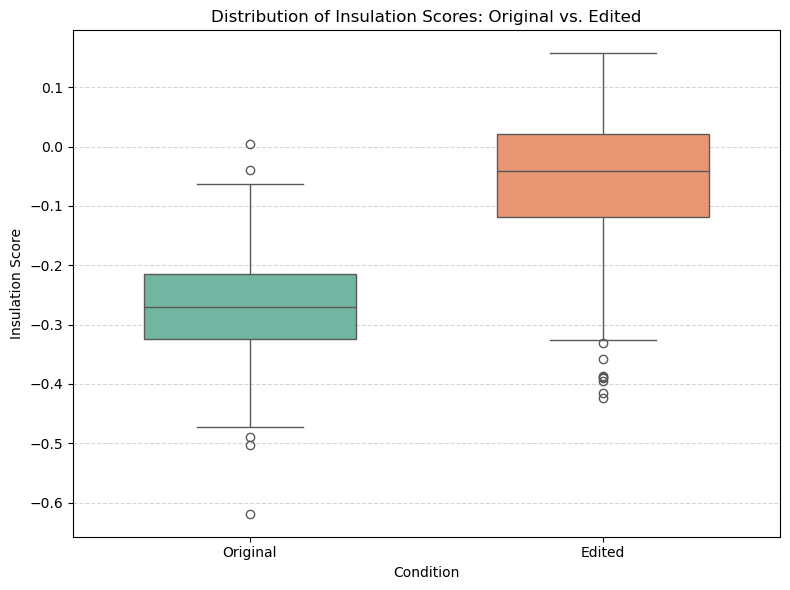

In [6]:
# 2. Reshape the dataframe for plotting
# This converts columns 'insul_score_orig' and 'insul_score_edited' into a single 'Value' column
# and a 'Score Type' column that labels each row.
melted_df = df.melt(
    id_vars=['optimization_success'], 
    value_vars=['insul_score_orig', 'insul_score_edited'], 
    var_name='Score Type', 
    value_name='Insulation Score'
)

# 3. Clean up labels for the plot
melted_df['Score Type'] = melted_df['Score Type'].replace({
    'insul_score_orig': 'Original', 
    'insul_score_edited': 'Edited'
})

# 4. Create the plot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=melted_df, 
    x='Score Type', 
    y='Insulation Score', 
    palette='Set2',
    width=0.6
)

# Optional: Add points to see the distribution (especially if you have a small dataset)
# sns.stripplot(data=melted_df, x='Score Type', y='Insulation Score', color='black', alpha=0.3)

plt.title('Distribution of Insulation Scores: Original vs. Edited')
plt.xlabel('Condition')
plt.ylabel('Insulation Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

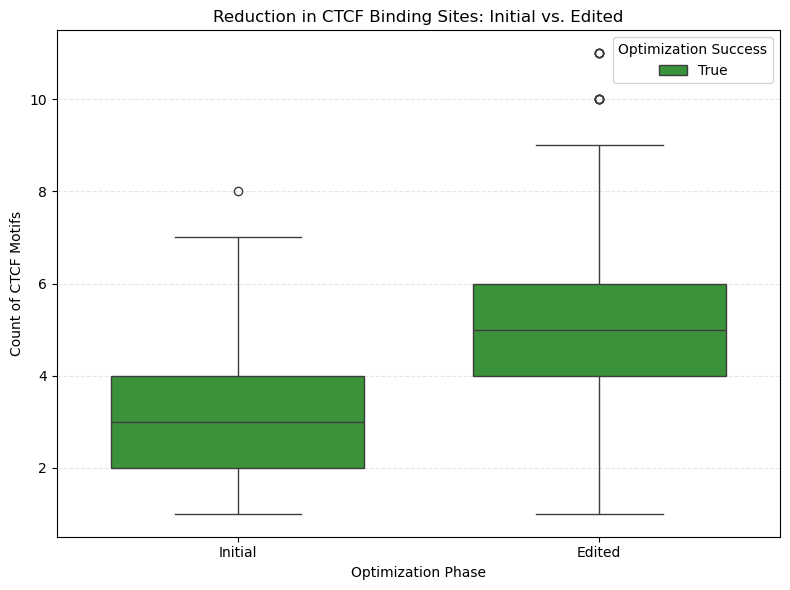

In [7]:
# 2. Reshape the dataframe for CTCF counts
melted_ctcf = df.melt(
    id_vars=['optimization_success'], 
    value_vars=['init_CTCFs_num', 'CTCFs_num'], 
    var_name='Condition', 
    value_name='Number of CTCF Sites'
)

# 3. Clean up labels for the plot
melted_ctcf['Condition'] = melted_ctcf['Condition'].replace({
    'init_CTCFs_num': 'Initial', 
    'CTCFs_num': 'Edited'
})

# 4. Create the plot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=melted_ctcf, 
    x='Condition', 
    y='Number of CTCF Sites', 
    hue='optimization_success', # This shows success vs failure side-by-side
    palette={True: "tab:green", False: "tab:red"}, # Green for success, Red for failure
    width=0.7
)

plt.title('Reduction in CTCF Binding Sites: Initial vs. Edited')
plt.xlabel('Optimization Phase')
plt.ylabel('Count of CTCF Motifs')
plt.legend(title='Optimization Success', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()